In [1]:
library(tidyverse)
library(dplyr)
library(ggplot2)
library(BSDA)
library(cowplot)

── Attaching core tidyverse packages ───────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ─────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: lattice──────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘BSDA’


The following object is masked from ‘package:datasets’:

    Orange



Attaching package: ‘cowplot’


The following object is

# File loading ----------------------------------------------------------------------------

In [2]:
# Read file
    fp_tp2 <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/vaginal/tp2_nulliparous/2025-11-11_fp_tp2_filt.csv", header = TRUE)
    sp_tp2 <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/vaginal/tp2_nulliparous/2025-11-11_sp_tp2_filt.csv", header = TRUE)
combined_fp_sp_tp2 <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/vaginal/tp2_nulliparous/2025-11-11_combined_fp_sp_tp2.csv", header = TRUE)

In [3]:
head(fp_tp2)
dim(fp_tp2)

,X,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,⋯,diffdays,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis
,<int>,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,⋯,<int>,<lgl>,<lgl>,<lgl>,<lgl>,<int>,<chr>,<lgl>,<lgl>,<int>
1,5367,S194e21b,NA,0,0,0,2018-11-16,P159f9c8,0,36,⋯,0,NA,NA,NA,NA,41,Spontaneous,NA,NA,0
2,5258,S1f95844,NA,0,0,0,2018-04-10,P1f95844,0,30,⋯,0,NA,NA,NA,NA,40,Spontaneous,NA,NA,0
3,5275,S2b86cc0,NA,0,0,0,2019-05-29,P3cac7b0,0,31,⋯,0,NA,NA,NA,NA,39,Spontaneous,NA,NA,0
4,5243,S39fe1d7,NA,0,0,0,2018-06-23,P3db7da6,0,29,⋯,0,NA,NA,NA,NA,41,Spontaneous,NA,NA,0
5,5383,S7e4a963,NA,0,0,0,2018-02-18,P424fd61,0,37,⋯,0,NA,NA,NA,NA,38,Induction,NA,NA,0
6,5239,S5fa4a39,NA,0,0,0,2018-08-30,P4de45e7,0,29,⋯,0,NA,NA,NA,NA,39,Induction,NA,NA,1


[1]  16 566

In [4]:
head(sp_tp2)
dim(sp_tp2)

,X,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,⋯,diffdays,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis
,<int>,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,⋯,<int>,<lgl>,<lgl>,<lgl>,<lgl>,<int>,<chr>,<lgl>,<lgl>,<int>
1,5391,S159f9c8,NA,0,0,0,2021-01-28,P159f9c8,0,38,⋯,0,NA,NA,NA,NA,40,Spontaneous,NA,NA,0
2,5309,S0e78496,NA,0,0,0,2020-12-17,P1f95844,0,33,⋯,0,NA,NA,NA,NA,39,Spontaneous,NA,NA,0
3,5311,S3cac7b0,NA,0,0,0,2020-10-20,P3cac7b0,0,33,⋯,0,NA,NA,NA,NA,40,Spontaneous,NA,NA,0
4,5252,S3db7da6,NA,0,0,1,2019-09-24,P3db7da6,0,30,⋯,0,NA,NA,NA,NA,39,Spontaneous,NA,NA,0
5,5415,S424fd61,NA,0,0,0,2020-11-03,P424fd61,0,40,⋯,31,NA,NA,NA,NA,38,Spontaneous,NA,NA,0
6,5272,S4de45e7,NA,0,0,0,2020-11-05,P4de45e7,0,31,⋯,0,NA,NA,NA,NA,40,Spontaneous,NA,NA,0


[1]  16 566

In [5]:
head(combined_fp_sp_tp2)
dim(combined_fp_sp_tp2)

,X,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,⋯,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis,Group
,<int>,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,⋯,<lgl>,<lgl>,<lgl>,<lgl>,<int>,<chr>,<lgl>,<lgl>,<int>,<chr>
1,5367,S194e21b,NA,0,0,0,2018-11-16,P159f9c8,0,36,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
2,5258,S1f95844,NA,0,0,0,2018-04-10,P1f95844,0,30,⋯,NA,NA,NA,NA,40,Spontaneous,NA,NA,0,First pregnancy
3,5275,S2b86cc0,NA,0,0,0,2019-05-29,P3cac7b0,0,31,⋯,NA,NA,NA,NA,39,Spontaneous,NA,NA,0,First pregnancy
4,5243,S39fe1d7,NA,0,0,0,2018-06-23,P3db7da6,0,29,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
5,5383,S7e4a963,NA,0,0,0,2018-02-18,P424fd61,0,37,⋯,NA,NA,NA,NA,38,Induction,NA,NA,0,First pregnancy
6,5239,S5fa4a39,NA,0,0,0,2018-08-30,P4de45e7,0,29,⋯,NA,NA,NA,NA,39,Induction,NA,NA,1,First pregnancy


[1]  32 567

# Quantitative, continuous ============================================================================================

## Age ---------------------------------------------------------------

In [6]:
dye <- c("First pregnancy " = "#F0E442", "Second pregnancy" = "#56B4E9")
combined_fp_sp_tp2$Group

[1] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
 [5] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
 [9] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[13] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[17] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[21] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[25] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[29] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"

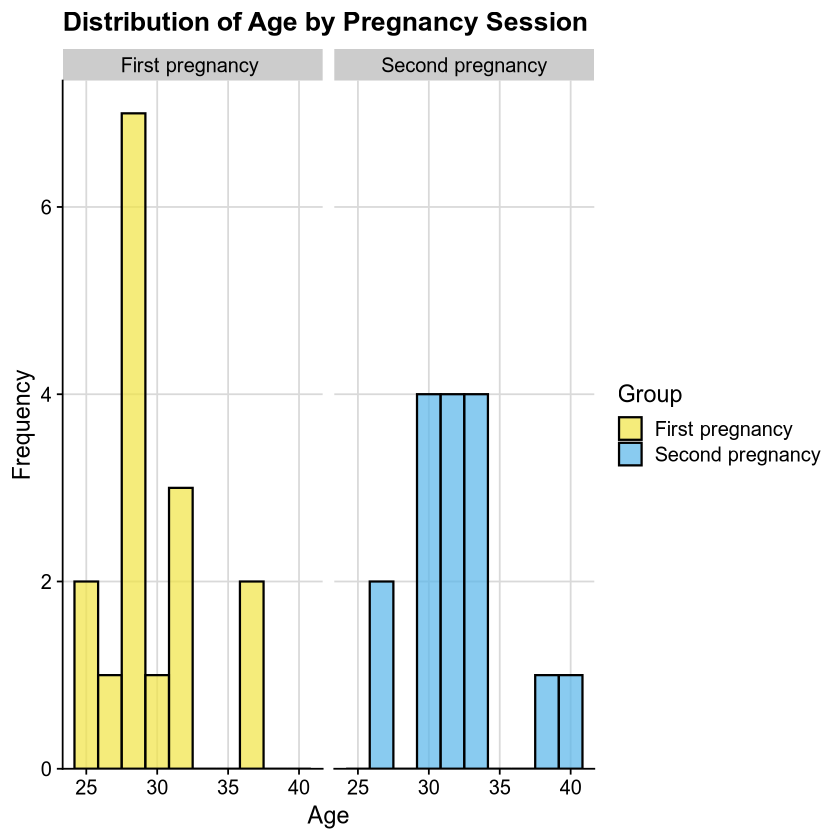

In [7]:
# Histogram of age distribution, grouped by pregnancy session (First vs Second)
age_histogram_combined <- combined_fp_sp_tp2 |>
  ggplot(aes(x = age_checked, fill = Group)) +
  geom_histogram(bins = 10, col="black", alpha = 0.7, na.rm = TRUE)+
  facet_wrap(~ Group) + # Create one histogram per group 
  labs(
    x = "Age",
    y ="Frequency",
    title ="Distribution of Age by Pregnancy Session"
  ) +
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +    
    scale_fill_manual(values = dye) 
age_histogram_combined + theme_half_open() +
  background_grid()

In [8]:
# Shapiro test
shapiro_first <- shapiro.test(combined_fp_sp_tp2$age_checked)
shapiro_first


	Shapiro-Wilk normality test

data:  combined_fp_sp_tp2$age_checked
W = 0.93202, p-value = 0.0446


In [9]:
test_age <- wilcox.test( combined_fp_sp_tp2$age_checked[combined_fp_sp_tp2$Group == "First pregnancy "],
  combined_fp_sp_tp2$age_checked[combined_fp_sp_tp2$Group == "Second pregnancy"],
  paired = TRUE)
test_age

Warning message in wilcox.test.default(combined_fp_sp_tp2$age_checked[combined_fp_sp_tp2$Group == :
“cannot compute exact p-value with ties”



	Wilcoxon signed rank test with continuity correction

data:  combined_fp_sp_tp2$age_checked[combined_fp_sp_tp2$Group == "First pregnancy "] and combined_fp_sp_tp2$age_checked[combined_fp_sp_tp2$Group == "Second pregnancy"]
V = 0, p-value = 0.0002804
alternative hypothesis: true location shift is not equal to 0


In [10]:
combined_fp_sp_sorted <- combined_fp_sp_tp2[order(combined_fp_sp_tp2$Q1_Personnummer, combined_fp_sp_tp2$Group)]
head(combined_fp_sp_sorted)

,X,Weight_before_C,Studienummer,BMI_prior,Correct_PN,Q1_X17_Weight_today,Prev_RPL,Q1_X6.0.Birth_country,Prev_IUFD,Cohabiting_or_not,⋯,Swedish_born,Q1_X13_Animal_contact,Q1_Family_status,Q1_X14_dog,Q1_X11_Educational_level,Q1_X14_cat,Q1_Education_uni_less,Q1_X14_rabbit,Height_C,Q1_X14_rodent
,<int>,<int>,<chr>,<int>,<lgl>,<int>,<int>,<chr>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>
1,5367,60,S194e21b,21,NA,72,0,Sverige,0,1,⋯,1,0,0,NA,Universitet/högskola,NA,0,NA,170,NA
2,5258,64,S1f95844,22,NA,65,0,Finland,0,1,⋯,0,0,0,NA,Universitet/högskola,NA,0,NA,170,NA
3,5275,56,S2b86cc0,21,NA,56,0,Tjeckien,0,1,⋯,0,1,0,1,Gymnasium,0,1,0,164,0
4,5243,55,S39fe1d7,21,NA,58,0,Sverige,0,1,⋯,1,0,0,NA,Gymnasium,NA,1,NA,161,NA
5,5383,67,S7e4a963,24,NA,69,0,Sverige,0,1,⋯,1,1,0,1,Universitet/högskola,0,0,0,167,0
6,5239,71,S5fa4a39,28,NA,76,0,Sverige,0,1,⋯,1,1,0,1,Universitet/högskola,1,0,0,159,0


### BMI 

In [11]:
wilcox_bmi <- wilcox.test(
  combined_fp_sp_tp2$BMI_prior[combined_fp_sp_tp2$Group == "First pregnancy "],
  combined_fp_sp_tp2$BMI_prior[combined_fp_sp_tp2$Group == "Second pregnancy"],
  paired = TRUE
)
wilcox_bmi

Warning message in wilcox.test.default(combined_fp_sp_tp2$BMI_prior[combined_fp_sp_tp2$Group == :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(combined_fp_sp_tp2$BMI_prior[combined_fp_sp_tp2$Group == :
“cannot compute exact p-value with zeroes”



	Wilcoxon signed rank test with continuity correction

data:  combined_fp_sp_tp2$BMI_prior[combined_fp_sp_tp2$Group == "First pregnancy "] and combined_fp_sp_tp2$BMI_prior[combined_fp_sp_tp2$Group == "Second pregnancy"]
V = 20, p-value = 0.03816
alternative hypothesis: true location shift is not equal to 0


# Categorical, Nominal data===============================================================================

## Excess weight

In [12]:
# Convert to factor
fp_tp2 <- fp_tp2 |>
  mutate(excess_weight = as.factor(ifelse(fp_tp2$Q1_X31_Diagnosed_PCOS == "NA", NA, ifelse(excess_weight =="No", 0, 1)))) 
sp_tp2 <- sp_tp2 |>
  mutate(excess_weight = as.factor(ifelse(sp_tp2$Q1_X31_Diagnosed_PCOS == "NA", NA, ifelse(excess_weight =="No", 0, 1)))) 

In [13]:
# Select variables of interest
fp_excess_weight <- fp_tp2 |>
  select(Q1_Personnummer, excess_weight)
sp_excess_weight <- sp_tp2 |>
  select(Q1_Personnummer, excess_weight)

In [14]:
combined_df_excess_weight <-  merge(fp_excess_weight, sp_excess_weight, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
dim(combined_df_excess_weight)

[1] 16  3

In [15]:
# Contingency table
tab_excess_weight <- table(combined_df_excess_weight$excess_weight_FP, combined_df_excess_weight$excess_weight_SP)
tab_excess_weight

   
    0 1
  0 5 5
  1 1 4

In [16]:

mcnemar.test(tab_excess_weight)


	McNemar's Chi-squared test with continuity correction

data:  tab_excess_weight
McNemar's chi-squared = 1.5, df = 1, p-value = 0.2207


## Diabetes----------------------------------------------------------------------

In [17]:
class(combined_fp_sp_tp2$Q2_X13.1.Pregproblem_gestational_diabetes)

[1] "character"

In [18]:
# Convert from char to fct
diabetes_category_fp <- ifelse(fp_tp2$Q2_X13.1.Pregproblem_gestational_diabetes == "Nej", 0, 
                            ifelse(fp_tp2$Q2_X13.1.Pregproblem_gestational_diabetes == "Ja", 1, NA))
diabetes_category_fp

diabetes_category_sp <- ifelse(sp_tp2$Q2_X13.1.Pregproblem_gestational_diabetes == "Nej", 0, 
                            ifelse(sp_tp2$Q2_X13.1.Pregproblem_gestational_diabetes == "Ja", 1, NA))
diabetes_category_sp

[1]  0 NA  0 NA NA NA NA NA NA NA NA NA NA  0 NA NA

[1] NA NA NA NA NA NA  0 NA  0 NA NA NA NA NA NA NA

In [19]:
# Add diabetes category column as factors
fp_tp2$Q2_Diabetes_category <- as.factor(diabetes_category_fp)
class(fp_tp2$Q2_Diabetes_category)

sp_tp2$Q2_Diabetes_category <- as.factor(diabetes_category_sp)
class(sp_tp2$Q2_Diabetes_category)

[1] "factor"

[1] "factor"

In [20]:
# Select variables of interest
fp_diabetes <- fp_tp2 |>
  select(Q1_Personnummer, Q2_Diabetes_category)
fp_diabetes

sp_diabetes <- sp_tp2 |>
  select(Q1_Personnummer, Q2_Diabetes_category)
sp_diabetes

Q1_Personnummer,Q2_Diabetes_category
<chr>,<fct>
P159f9c8,0
P1f95844,NA
P3cac7b0,0
P3db7da6,NA
P424fd61,NA
P4de45e7,NA
P5b98b6c,NA
P62ea0b2,NA
P719b21e,NA


Q1_Personnummer,Q2_Diabetes_category
<chr>,<fct>
P159f9c8,NA
P1f95844,NA
P3cac7b0,NA
P3db7da6,NA
P424fd61,NA
P4de45e7,NA
P5b98b6c,0
P62ea0b2,NA
P719b21e,0


In [21]:
combined_df_diabetes <-  merge(fp_diabetes, sp_diabetes, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
dim(combined_df_diabetes)

[1] 16  3

In [22]:
# Pull personal# where NA for EITHER pregnancy but NOT na for the other pregnancy
# This way get separate lists for fp and sp personal#
# NA ONLY for fp
missing_pn_diabetes_fp <- combined_df_diabetes |> filter(is.na(combined_df_diabetes$Q2_Diabetes_category_FP) & !is.na(combined_df_diabetes$Q2_Diabetes_category_SP)) |> 
  pull(Q1_Personnummer)
missing_pn_diabetes_fp

[1] "P5b98b6c" "P719b21e"

In [23]:
# NA ONLY for sp
missing_pn_diabetes_sp <- combined_df_diabetes |> filter(is.na(combined_df_diabetes$Q2_Diabetes_category_SP) & !is.na(combined_df_diabetes$Q2_Diabetes_category_FP)) |> 
  pull(Q1_Personnummer)
missing_pn_diabetes_sp

[1] "P159f9c8" "P3cac7b0" "Pc77a35c"

In [24]:
# Pull personal# where NA for BOTH fp AND sp
missing_pn_diabetes_both <- combined_df_diabetes |> filter(is.na(combined_df_diabetes$Q2_Diabetes_category_FP) & is.na(combined_df_diabetes$Q2_Diabetes_category_SP)) |> 
  pull(Q1_Personnummer)
missing_pn_diabetes_both
length(missing_pn_diabetes_both)

[1] "P1f95844" "P3db7da6" "P424fd61" "P4de45e7" "P62ea0b2" "P7ece52e"
 [7] "P97574f9" "P9cdfd5a" "Pbe289c8" "Pca94a0f" "Pdab1897"

[1] 11

## Depression--------------------------------------------------------------------

In [25]:
 # Convert to categories
depression_category_fp <- ifelse(fp_tp2$Depression_score_sum_Q2 >= 0 & fp_tp2$Depression_score_sum_Q2 < 13, 0, 
                                 ifelse(fp_tp2$Depression_score_sum_Q2 >= 13 & fp_tp2$Depression_score_sum_Q2 <= 30, 1, NA))
depression_category_fp

depression_category_sp <- ifelse(sp_tp2$Depression_score_sum_Q2 >= 0 & sp_tp2$Depression_score_sum_Q2 < 13,  0, 
                                 ifelse(sp_tp2$Depression_score_sum_Q2 >= 13 & sp_tp2$Depression_score_sum_Q2 <= 30, 1, NA))
depression_category_sp

[1]  0 NA  0  0  0  0  0  0  0  1  0 NA  0  0 NA  0

[1]  0  0  0  1  0  0  0  0  0  0  0 NA  0  1  1  0

In [26]:
# Add depression category column
fp_tp2$Q2_Depression_category <- as.factor(depression_category_fp)
sp_tp2$Q2_Depression_category <- as.factor(depression_category_sp)
class(fp_tp2$Q2_Depression_category)

[1] "factor"

In [27]:
fp_depression <- fp_tp2 |>
  select(Q1_Personnummer, Q2_Depression_category)
sp_depression <- sp_tp2 |>
  select(Q1_Personnummer, Q2_Depression_category)

In [28]:
combined_df_depression <- merge(fp_depression, sp_depression, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
combined_df_depression |> head()
dim(combined_df_depression) 

,Q1_Personnummer,Q2_Depression_category_FP,Q2_Depression_category_SP
,<chr>,<fct>,<fct>
1,P159f9c8,0,0
2,P1f95844,NA,0
3,P3cac7b0,0,0
4,P3db7da6,0,1
5,P424fd61,0,0
6,P4de45e7,0,0


[1] 16  3

In [29]:
tab_depression <- table(combined_df_depression$Q2_Depression_category_FP, combined_df_depression$Q2_Depression_category_SP)
tab_depression

   
     0  1
  0 10  2
  1  1  0

In [30]:
mcnemar.test(tab_depression)


	McNemar's Chi-squared test with continuity correction

data:  tab_depression
McNemar's chi-squared = 0, df = 1, p-value = 1


## Stress------------------------------------------------------------------------

In [31]:
table(combined_fp_sp_tp2$stress_sum_score_Q2)


 0  1  2  3  4  5  6  7  8  9 11 12 
 1  2  3  3  4  6  6  2  1  2  1  1 

In [32]:
# There was no high stress column for Q2
# Convert stress score to categories
high_stress_Q2_fp <- ifelse(fp_tp2$stress_sum_score_Q2 >= 7, 1, ifelse(fp_tp2$stress_sum_score_Q2 < 7 , 0, NA))
table(high_stress_Q2_fp)
length(fp_tp2$stress_sum_score_Q2)

high_stress_Q2_sp <- ifelse(sp_tp2$stress_sum_score_Q2 >= 7, 1, ifelse(sp_tp2$stress_sum_score_Q2 < 7 , 0, NA))
table(high_stress_Q2_sp)
length(sp_tp2$stress_sum_score_Q2)

high_stress_Q2_fp
 0  1 
13  3 

[1] 16

high_stress_Q2_sp
 0  1 
12  4 

[1] 16

In [33]:
# Create new column with yes/no for high stress
fp_tp2$high_stress_Q2_fp <- high_stress_Q2_fp
table(fp_tp2$high_stress_Q2_fp)

sp_tp2$high_stress_Q2_sp <- high_stress_Q2_sp
table(sp_tp2$high_stress_Q2_sp)


 0  1 
13  3 


 0  1 
12  4 

In [34]:
# Select variables 
fp_stress <- fp_tp2 |>
  select(Q1_Personnummer, high_stress_Q2_fp)
fp_stress

sp_stress <- sp_tp2 |>
  select(Q1_Personnummer, high_stress_Q2_sp)
sp_stress

Q1_Personnummer,high_stress_Q2_fp
<chr>,<dbl>
P159f9c8,0
P1f95844,1
P3cac7b0,0
P3db7da6,1
P424fd61,0
P4de45e7,0
P5b98b6c,0
P62ea0b2,0
P719b21e,0


Q1_Personnummer,high_stress_Q2_sp
<chr>,<dbl>
P159f9c8,0
P1f95844,0
P3cac7b0,0
P3db7da6,1
P424fd61,0
P4de45e7,0
P5b98b6c,0
P62ea0b2,0
P719b21e,0


In [35]:
combined_df_stress <- merge(fp_stress, sp_stress, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
combined_df_stress

Q1_Personnummer,high_stress_Q2_fp,high_stress_Q2_sp
<chr>,<dbl>,<dbl>
P159f9c8,0,0
P1f95844,1,0
P3cac7b0,0,0
P3db7da6,1,1
P424fd61,0,0
P4de45e7,0,0
P5b98b6c,0,0
P62ea0b2,0,0
P719b21e,0,0


In [36]:
tab_stress <- table(combined_df_stress$high_stress_Q2_fp, combined_df_stress$high_stress_Q2_sp)
tab_stress

   
     0  1
  0 11  2
  1  1  2

In [37]:
mcnemar.test(tab_stress)


	McNemar's Chi-squared test with continuity correction

data:  tab_stress
McNemar's chi-squared = 0, df = 1, p-value = 1


## Smoking-----------------------------------------------------------------------

In [38]:
combined_fp_sp_tp2$Q2_X25_Smoking_snus_now

[1] "Nej" "Nej" "Nej" "Nej" "Nej" "Nej" "Nej" "Nej" "Nej" "Nej" "Nej" "Nej"
[13] "Nej" "Nej" "Nej" "Nej" "Nej" "Nej" "Nej" "Nej" "Nej" "Nej" "Nej" "Nej"
[25] "Nej" "Nej" "Nej" "Nej" "Nej" "Nej" "Nej" "Nej"

In [39]:
# Convert to categories 
smoking_category_fp <- ifelse(fp_tp2$Q2_X25_Smoking_snus_now == "Nej", 0, 
                           ifelse(fp_tp2$Q2_X25_Smoking_snus_now == "Ja", 1, NA))
table(smoking_category_fp)

smoking_category_sp <- ifelse(sp_tp2$Q2_X25_Smoking_snus_now == "Nej", 0, 
                              ifelse(sp_tp2$Q2_X25_Smoking_snus_now == "Ja", 1, NA))
table(smoking_category_sp)

smoking_category_fp
 0 
16 

smoking_category_sp
 0 
16 

In [40]:
# Check for NA
sum(is.na(smoking_category_fp))
sum(is.na(smoking_category_sp))

[1] 0

[1] 0

In [41]:
fp_tp2$smoking_category_Q2 <- smoking_category_fp
fp_tp2$smoking_category_Q2

sp_tp2$smoking_category_Q2 <- smoking_category_sp
sp_tp2$smoking_category_Q2

[1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

[1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [42]:
fp_smoking <- fp_tp2 |>
  select(Q1_Personnummer, smoking_category_Q2)
fp_smoking

sp_smoking <-  sp_tp2 |>
  select(Q1_Personnummer, smoking_category_Q2)
sp_smoking

Q1_Personnummer,smoking_category_Q2
<chr>,<dbl>
P159f9c8,0
P1f95844,0
P3cac7b0,0
P3db7da6,0
P424fd61,0
P4de45e7,0
P5b98b6c,0
P62ea0b2,0
P719b21e,0


Q1_Personnummer,smoking_category_Q2
<chr>,<dbl>
P159f9c8,0
P1f95844,0
P3cac7b0,0
P3db7da6,0
P424fd61,0
P4de45e7,0
P5b98b6c,0
P62ea0b2,0
P719b21e,0


In [43]:
combined_df_smoking <- merge(fp_smoking, sp_smoking, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
combined_df_smoking

Q1_Personnummer,smoking_category_Q2_FP,smoking_category_Q2_SP
<chr>,<dbl>,<dbl>
P159f9c8,0,0
P1f95844,0,0
P3cac7b0,0,0
P3db7da6,0,0
P424fd61,0,0
P4de45e7,0,0
P5b98b6c,0,0
P62ea0b2,0,0
P719b21e,0,0


In [44]:
# NA ONLY for fp
missing_pn_smoking_fp <- combined_df_smoking |> filter(is.na(combined_df_smoking$smoking_category_Q2_FP) & !is.na(combined_df_smoking$smoking_category_Q2_SP)) |> 
  pull(Q1_Personnummer)
missing_pn_smoking_fp

character(0)

In [45]:
# NA ONLY for sp
missing_pn_smoking_sp <- combined_df_smoking |> filter(is.na(combined_df_smoking$smoking_category_Q2_SP) & !is.na(combined_df_smoking$smoking_category_Q2_FP)) |> 
  pull(Q1_Personnummer)
missing_pn_smoking_sp

character(0)

In [46]:
# Pull personal# where NA for BOTH fp AND sp
missing_pn_smoking_both <- combined_df_smoking |> filter(is.na(combined_df_smoking$smoking_category_Q2_FP) & is.na(combined_df_smoking$smoking_category_Q2_SP)) |> 
  pull(Q1_Personnummer)
missing_pn_smoking_both
length(missing_pn_smoking_both)

character(0)

[1] 0

## Alcohol-----------------------------------------------------------------------

In [47]:
combined_fp_sp_tp2$Q2_X28_How_often_alcohol_since_pregnancy

[1] "Aldrig" "Aldrig" "Aldrig" "Aldrig" "Aldrig" "Aldrig" "Aldrig" "Aldrig"
 [9] "Aldrig" "Aldrig" "Aldrig" "Aldrig" "Aldrig" "Aldrig" "Aldrig" "Aldrig"
[17] "Aldrig" "Aldrig" "Aldrig" "Aldrig" "Aldrig" "Aldrig" "Aldrig" "Aldrig"
[25] "Aldrig" "Aldrig" "Aldrig" "Aldrig" "Aldrig" "Aldrig" "Aldrig" "Aldrig"

In [48]:
alcohol_category_fp <- ifelse(fp_tp2$Q2_X28_How_often_alcohol_since_pregnancy == "Aldrig", 0, NA)
table(alcohol_category_fp)

alcohol_category_sp <- ifelse(sp_tp2$Q2_X28_How_often_alcohol_since_pregnancy == "Aldrig", 0, NA)
table(alcohol_category_sp)

alcohol_category_fp
 0 
16 

alcohol_category_sp
 0 
16 

In [49]:
# Check for NA
sum(is.na(alcohol_category_fp))
sum(is.na(alcohol_category_sp))

[1] 0

[1] 0

In [50]:
fp_tp2$alcohol_category_Q2 <- alcohol_category_fp
fp_tp2$alcohol_category_Q2

sp_tp2$alcohol_category_Q2 <- alcohol_category_sp
sp_tp2$alcohol_category_Q2

[1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

[1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [51]:
fp_alcohol <- fp_tp2 |>
  select(Q1_Personnummer, alcohol_category_Q2)
fp_alcohol

sp_alcohol <- sp_tp2 |>
  select(Q1_Personnummer, alcohol_category_Q2)
sp_alcohol

Q1_Personnummer,alcohol_category_Q2
<chr>,<dbl>
P159f9c8,0
P1f95844,0
P3cac7b0,0
P3db7da6,0
P424fd61,0
P4de45e7,0
P5b98b6c,0
P62ea0b2,0
P719b21e,0


Q1_Personnummer,alcohol_category_Q2
<chr>,<dbl>
P159f9c8,0
P1f95844,0
P3cac7b0,0
P3db7da6,0
P424fd61,0
P4de45e7,0
P5b98b6c,0
P62ea0b2,0
P719b21e,0


In [52]:
combined_df_alcohol <- merge(fp_alcohol, sp_alcohol, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
combined_df_alcohol

Q1_Personnummer,alcohol_category_Q2_FP,alcohol_category_Q2_SP
<chr>,<dbl>,<dbl>
P159f9c8,0,0
P1f95844,0,0
P3cac7b0,0,0
P3db7da6,0,0
P424fd61,0,0
P4de45e7,0,0
P5b98b6c,0,0
P62ea0b2,0,0
P719b21e,0,0


## Antibiotic--------------------------------------------------------------------

In [53]:
class(combined_fp_sp_tp2$Q2_X6.Antibiotics_during_pregnancy)
table(combined_fp_sp_tp2$Q2_X6.Antibiotics_during_pregnancy)

[1] "integer"


 0  1 
30  2 

In [54]:
fp_tp2$Q2_X6.Antibiotics_during_pregnancy <- as.factor(fp_tp2$Q2_X6.Antibiotics_during_pregnancy )
sp_tp2$Q2_X6.Antibiotics_during_pregnancy <- as.factor(sp_tp2$Q2_X6.Antibiotics_during_pregnancy )
class(fp_tp2$Q2_X6.Antibiotics_during_pregnancy)
class(sp_tp2$Q2_X6.Antibiotics_during_pregnancy)

[1] "factor"

[1] "factor"

In [55]:
fp_anti <- fp_tp2 |> 
  select(Q1_Personnummer, Q2_X6.Antibiotics_during_pregnancy) 
sp_anti <- sp_tp2 |>
  select(Q1_Personnummer, Q2_X6.Antibiotics_during_pregnancy) 

In [56]:
combined_df_anti <- merge(fp_anti, sp_anti, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))

In [57]:
head(combined_df_anti)
dim(combined_df_anti)

,Q1_Personnummer,Q2_X6.Antibiotics_during_pregnancy_FP,Q2_X6.Antibiotics_during_pregnancy_SP
,<chr>,<fct>,<fct>
1,P159f9c8,0,0
2,P1f95844,0,0
3,P3cac7b0,0,1
4,P3db7da6,1,0
5,P424fd61,0,0
6,P4de45e7,0,0


[1] 16  3

In [58]:
combined_df_anti

Q1_Personnummer,Q2_X6.Antibiotics_during_pregnancy_FP,Q2_X6.Antibiotics_during_pregnancy_SP
<chr>,<fct>,<fct>
P159f9c8,0,0
P1f95844,0,0
P3cac7b0,0,1
P3db7da6,1,0
P424fd61,0,0
P4de45e7,0,0
P5b98b6c,0,0
P62ea0b2,0,0
P719b21e,0,0


In [59]:
# Create contingency table with two levels
tab_anti <- table(
  factor(combined_df_anti$Q2_X6.Antibiotics_during_pregnancy_FP, levels = c(0, 1)),
      factor(combined_df_anti$Q2_X6.Antibiotics_during_pregnancy_SP, levels = c(0, 1))
)
tab_anti

   
     0  1
  0 14  1
  1  1  0

In [60]:
# Non-parametric paired categorical data --> use McNemar's test
mcnemar.test(tab_anti)


	McNemar's Chi-squared test

data:  tab_anti
McNemar's chi-squared = 0, df = 1, p-value = 1


## Diet--------------------------------------------------------------------------

All participants had the same score for both fp and sp --> no significant diffv possible

## Daily Fiber-------------------------------------------------------------------

In [66]:
class(combined_fp_sp_tp2$Q2_dailyfiber)

[1] "integer"

In [67]:
fp_fiber <- fp_tp2 |>
  select(Q1_Personnummer, Q2_dailyfiber)
fp_fiber

Q1_Personnummer,Q2_dailyfiber
<chr>,<int>
P159f9c8,1
P1f95844,1
P3cac7b0,0
P3db7da6,1
P424fd61,1
P4de45e7,0
P5b98b6c,1
P62ea0b2,1
P719b21e,1


In [68]:
sp_fiber <- sp_tp2 |>
  select(Q1_Personnummer, Q2_dailyfiber)
sp_fiber

Q1_Personnummer,Q2_dailyfiber
<chr>,<int>
P159f9c8,1
P1f95844,1
P3cac7b0,1
P3db7da6,1
P424fd61,1
P4de45e7,0
P5b98b6c,1
P62ea0b2,1
P719b21e,1


In [69]:
combined_df_fiber <- merge(fp_fiber, sp_fiber, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
combined_df_fiber

Q1_Personnummer,Q2_dailyfiber_FP,Q2_dailyfiber_SP
<chr>,<int>,<int>
P159f9c8,1,1
P1f95844,1,1
P3cac7b0,0,1
P3db7da6,1,1
P424fd61,1,1
P4de45e7,0,0
P5b98b6c,1,1
P62ea0b2,1,1
P719b21e,1,1


In [70]:
tab_fiber <- table(combined_df_fiber$Q2_dailyfiber_FP, combined_df_fiber$Q2_dailyfiber_SP)
tab_fiber

   
     0  1
  0  2  2
  1  0 12

In [71]:
mcnemar.test(tab_fiber)


	McNemar's Chi-squared test with continuity correction

data:  tab_fiber
McNemar's chi-squared = 0.5, df = 1, p-value = 0.4795


## Hypertension---------------------------------------------------------------------------------------

In [72]:
class(combined_fp_sp_tp2$Q2_bloodpressure)

fp_tp2$Q2_bloodpressure <- as.factor(fp_tp2$Q2_bloodpressure)
sp_tp2$Q2_bloodpressure <- as.factor(sp_tp2$Q2_bloodpressure)
combined_fp_sp_tp2$Q2_bloodpressure <- as.factor(combined_fp_sp_tp2$Q2_bloodpressure)

[1] "integer"

In [73]:
class(fp_tp2$Q2_bloodpressure)

[1] "factor"

In [74]:
fp_BP <- fp_tp2 |>
  select(Q1_Personnummer, Q2_bloodpressure)
head(fp_BP)

sp_BP <- sp_tp2 |>
  select(Q1_Personnummer, Q2_bloodpressure)
head(sp_BP)

,Q1_Personnummer,Q2_bloodpressure
,<chr>,<fct>
1,P159f9c8,1
2,P1f95844,0
3,P3cac7b0,0
4,P3db7da6,0
5,P424fd61,0
6,P4de45e7,0


,Q1_Personnummer,Q2_bloodpressure
,<chr>,<fct>
1,P159f9c8,0
2,P1f95844,0
3,P3cac7b0,0
4,P3db7da6,0
5,P424fd61,0
6,P4de45e7,1


In [75]:
combined_df_BP <- merge(fp_BP, sp_BP, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
head(combined_df_BP)

,Q1_Personnummer,Q2_bloodpressure_FP,Q2_bloodpressure_SP
,<chr>,<fct>,<fct>
1,P159f9c8,1,0
2,P1f95844,0,0
3,P3cac7b0,0,0
4,P3db7da6,0,0
5,P424fd61,0,0
6,P4de45e7,0,1


In [76]:
tab_BP <- table(combined_df_BP$Q2_bloodpressure_FP, combined_df_BP$Q2_bloodpressure_SP)
tab_BP

   
     0  1
  0 12  1
  1  2  1

In [77]:
mcnemar.test(tab_BP)


	McNemar's Chi-squared test with continuity correction

data:  tab_BP
McNemar's chi-squared = 0, df = 1, p-value = 1


## PCOS ----------------------------------------------------------------------------

In [78]:
class(combined_fp_sp_tp2$Q1_X31_Diagnosed_PCOS)

[1] "character"

In [79]:
fp_tp2 <- fp_tp2 |>
  mutate(Q1_X31_Diagnosed_PCOS = as.factor(ifelse(fp_tp2$Q1_X31_Diagnosed_PCOS == "Vet inte", NA, ifelse(fp_tp2$Q1_X31_Diagnosed_PCOS == "Nej", 0, 1))))
sp_tp2 <- sp_tp2 |>
  mutate(Q1_X31_Diagnosed_PCOS = as.factor(ifelse (sp_tp2$Q1_X31_Diagnosed_PCOS == "Vet inte", NA, ifelse(sp_tp2$Q1_X31_Diagnosed_PCOS == "Nej", 0, 1))))
class(fp_tp2$Q1_X31_Diagnosed_PCOS)
class(sp_tp2$Q1_X31_Diagnosed_PCOS)

[1] "factor"

[1] "factor"

In [80]:
fp_pcos <- fp_tp2 |>
  select(Q1_Personnummer, Q1_X31_Diagnosed_PCOS)
sp_pcos <- sp_tp2 |>
  select(Q1_Personnummer, Q1_X31_Diagnosed_PCOS)
 

In [81]:
combined_df_pcos <- merge(fp_pcos, sp_pcos, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))

In [82]:
tab_pcos <- table(combined_df_pcos$Q1_X31_Diagnosed_PCOS_FP, combined_df_pcos$Q1_X31_Diagnosed_PCOS_SP)

In [83]:
mcnemar.test(tab_pcos)


	McNemar's Chi-squared test with continuity correction

data:  tab_pcos
McNemar's chi-squared = 0, df = 1, p-value = 1


## Dentist --------------------------------------------------------------------

In [84]:
fp_tp2$Q1_X50_Dentist_3_months_before_pregnancy <- as.factor(fp_tp2$Q1_X50_Dentist_3_months_before_pregnancy)
fp_tp2$Q1_X50_Dentist_3_months_before_pregnancy
fp_tp2$Q1_X50_Dentist_3_months_before_pregnancy |> class()

[1] 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0
Levels: 0 1

[1] "factor"

In [85]:
sp_tp2$Q1_X50_Dentist_3_months_before_pregnancy <- as.factor(sp_tp2$Q1_X50_Dentist_3_months_before_pregnancy)
sp_tp2$Q1_X50_Dentist_3_months_before_pregnancy
sp_tp2$Q1_X50_Dentist_3_months_before_pregnancy |> class()

[1] 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1
Levels: 0 1

[1] "factor"

In [ ]:
fp_dentist <- fp_tp2 |>
  select(Q1_Personnummer, Q1_X50_Dentist_3_months_before_pregnancy)
sp_dentist <- sp_tp2 |>
  select(Q1_Personnummer, Q1_X50_Dentist_3_months_before_pregnancy)
 

In [87]:
combined_df_dentist <- merge(fp_dentist, sp_dentist, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
combined_df_dentist |> head()

,Q1_Personnummer,Q1_X50_Dentist_3_months_before_pregnancy_FP,Q1_X50_Dentist_3_months_before_pregnancy_SP
,<chr>,<fct>,<fct>
1,P159f9c8,0,0
2,P1f95844,0,1
3,P3cac7b0,0,0
4,P3db7da6,0,0
5,P424fd61,0,0
6,P4de45e7,1,0


In [88]:
tab_dentist <- table(combined_df_dentist$Q1_X50_Dentist_3_months_before_pregnancy_FP, combined_df_dentist$Q1_X50_Dentist_3_months_before_pregnancy_SP)
tab_dentist

   
     0  1
  0 10  3
  1  3  0

In [89]:
mcnemar.test(tab_dentist)


	McNemar's Chi-squared test

data:  tab_dentist
McNemar's chi-squared = 0, df = 1, p-value = 1


# Categorical, ordinal ---------------------------------------------------------------------------

## BMI

In [86]:
meta_BMI_update_fp <- fp_tp2 %>%
 mutate(
  BMI_group_prior = case_when(
   BMI_prior < 18.5 ~ "Underweight",
   BMI_prior >= 18.5 & BMI_prior <= 24.9 ~ "Normalweight",
   BMI_prior >= 25 & BMI_prior <= 29.9 ~ "Overweight",
   BMI_prior >= 30 ~ "Obese",
   TRUE ~ NA_character_  
 ))

head(meta_BMI_update_fp)
dim(meta_BMI_update_fp)

,X,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,⋯,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis,Q2_Diabetes_category,Q2_Depression_category,high_stress_Q2_fp,smoking_category_Q2,alcohol_category_Q2,BMI_group_prior
,<int>,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,⋯,<chr>,<lgl>,<lgl>,<int>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<chr>
1,5367,S194e21b,NA,0,0,0,2018-11-16,P159f9c8,0,36,⋯,Spontaneous,NA,NA,0,0,0,0,0,0,Normalweight
2,5258,S1f95844,NA,0,0,0,2018-04-10,P1f95844,0,30,⋯,Spontaneous,NA,NA,0,NA,NA,1,0,0,Normalweight
3,5275,S2b86cc0,NA,0,0,0,2019-05-29,P3cac7b0,0,31,⋯,Spontaneous,NA,NA,0,0,0,0,0,0,Normalweight
4,5243,S39fe1d7,NA,0,0,0,2018-06-23,P3db7da6,0,29,⋯,Spontaneous,NA,NA,0,NA,0,1,0,0,Normalweight
5,5383,S7e4a963,NA,0,0,0,2018-02-18,P424fd61,0,37,⋯,Induction,NA,NA,0,NA,0,0,0,0,Normalweight
6,5239,S5fa4a39,NA,0,0,0,2018-08-30,P4de45e7,0,29,⋯,Induction,NA,NA,1,NA,0,0,0,0,Overweight


[1]  16 572

In [87]:
meta_BMI_update_sp <- sp_tp2 %>%
 mutate(
  BMI_group_prior = case_when(
   BMI_prior < 18.5 ~ "Underweight",
   BMI_prior >= 18.5 & BMI_prior <= 24.9 ~ "Normalweight",
   BMI_prior >= 25 & BMI_prior <= 29.9 ~ "Overweight",
   BMI_prior >= 30 ~ "Obese",
   TRUE ~ NA_character_  
 ))

head(meta_BMI_update_sp)
dim(meta_BMI_update_sp)

,X,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,⋯,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis,Q2_Diabetes_category,Q2_Depression_category,high_stress_Q2_sp,smoking_category_Q2,alcohol_category_Q2,BMI_group_prior
,<int>,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,⋯,<chr>,<lgl>,<lgl>,<int>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<chr>
1,5391,S159f9c8,NA,0,0,0,2021-01-28,P159f9c8,0,38,⋯,Spontaneous,NA,NA,0,NA,0,0,0,0,Overweight
2,5309,S0e78496,NA,0,0,0,2020-12-17,P1f95844,0,33,⋯,Spontaneous,NA,NA,0,NA,0,0,0,0,Normalweight
3,5311,S3cac7b0,NA,0,0,0,2020-10-20,P3cac7b0,0,33,⋯,Spontaneous,NA,NA,0,NA,0,0,0,0,Normalweight
4,5252,S3db7da6,NA,0,0,1,2019-09-24,P3db7da6,0,30,⋯,Spontaneous,NA,NA,0,NA,1,1,0,0,Normalweight
5,5415,S424fd61,NA,0,0,0,2020-11-03,P424fd61,0,40,⋯,Spontaneous,NA,NA,0,NA,0,0,0,0,Normalweight
6,5272,S4de45e7,NA,0,0,0,2020-11-05,P4de45e7,0,31,⋯,Spontaneous,NA,NA,0,NA,0,0,0,0,Overweight


[1]  16 572

In [89]:
# Merge the two dataframes by personal numbers
fp_bmi <- meta_BMI_update_fp |>
  select(Q1_Personnummer, BMI_group_prior)
sp_bmi <- meta_BMI_update_sp |>
  select(Q1_Personnummer, BMI_group_prior)

In [90]:
bmi_merged <- merge(fp_bmi, sp_bmi, by = "Q1_Personnummer", suffixes = c("_fp", "_sp"))
head(bmi_merged)
dim(bmi_merged)

,Q1_Personnummer,BMI_group_prior_fp,BMI_group_prior_sp
,<chr>,<chr>,<chr>
1,P159f9c8,Normalweight,Overweight
2,P1f95844,Normalweight,Normalweight
3,P3cac7b0,Normalweight,Normalweight
4,P3db7da6,Normalweight,Normalweight
5,P424fd61,Normalweight,Normalweight
6,P4de45e7,Overweight,Overweight


[1] 16  3

In [91]:
sum(is.na(bmi_merged))

[1] 0

In [92]:
# Wherever there is a missing value, replace it with NA
bmi_merged[bmi_merged == "Missing"] <- NA
sum(is.na(bmi_merged))

[1] 0

In [93]:
head(bmi_merged)
dim(bmi_merged)

,Q1_Personnummer,BMI_group_prior_fp,BMI_group_prior_sp
,<chr>,<chr>,<chr>
1,P159f9c8,Normalweight,Overweight
2,P1f95844,Normalweight,Normalweight
3,P3cac7b0,Normalweight,Normalweight
4,P3db7da6,Normalweight,Normalweight
5,P424fd61,Normalweight,Normalweight
6,P4de45e7,Overweight,Overweight


[1] 16  3

In [94]:
# Drop the missing values, because it will effect the results
bmi_merged_clean <- bmi_merged |>
  filter(!is.na(BMI_group_prior_sp) & !is.na(BMI_group_prior_fp))

In [95]:
head(bmi_merged_clean)
dim(bmi_merged_clean)
sum(is.na(bmi_merged_clean))

,Q1_Personnummer,BMI_group_prior_fp,BMI_group_prior_sp
,<chr>,<chr>,<chr>
1,P159f9c8,Normalweight,Overweight
2,P1f95844,Normalweight,Normalweight
3,P3cac7b0,Normalweight,Normalweight
4,P3db7da6,Normalweight,Normalweight
5,P424fd61,Normalweight,Normalweight
6,P4de45e7,Overweight,Overweight


[1] 16  3

[1] 0

In [96]:
table(bmi_merged_clean$BMI_group_prior_fp)
table(bmi_merged_clean$BMI_group_prior_sp)


Normalweight   Overweight  Underweight 
          12            3            1 


Normalweight        Obese   Overweight  Underweight 
           9            1            5            1 

In [97]:
# Define the order of categories
bmi_levels <- c("Underweight", "Normal weight", "Overweight", "Obese")

In [98]:
#fp
bmi_merged_clean$BMI_group_prior_fp <- factor(bmi_merged_clean$BMI_group_prior_fp, levels = bmi_levels, ordered = TRUE)
class(bmi_merged_clean$BMI_group_prior_fp)

[1] "ordered" "factor"

In [99]:
#sp
bmi_merged_clean$BMI_group_prior_sp <- factor(bmi_merged_clean$BMI_group_prior_sp, levels = bmi_levels, ordered = TRUE)
class(bmi_merged_clean$BMI_group_prior_sp)

[1] "ordered" "factor"

In [100]:
# Compute the sign of the change
# Compare ordinal ranks
bmi_merged_clean$sign <- sign(as.numeric(bmi_merged_clean$BMI_group_prior_sp) - as.numeric(bmi_merged_clean$BMI_group_prior_fp))
bmi_merged_clean$sign 

[1] NA NA NA NA NA  0 NA NA  0  0 NA NA NA  1 NA NA

In [101]:
#sign = 1 BMI category increased
#sign = -1 BMI category decreased
#sign = 0 no change (tie)

table(bmi_merged_clean$sign)
sum(is.na(bmi_merged_clean$sign))


0 1 
3 1 

[1] 12

In [102]:
# Run the sign test 
SIGN.test(
  x = as.numeric(bmi_merged_clean$BMI_group_prior_sp),
  y = as.numeric(bmi_merged_clean$BMI_group_prior_fp),
  alternative = "two.sided",
  paired = TRUE
)


	Dependent-samples Sign-Test

data:  as.numeric(bmi_merged_clean$BMI_group_prior_sp) and as.numeric(bmi_merged_clean$BMI_group_prior_fp)
S = 1, p-value = 1
alternative hypothesis: true median difference is not equal to 0
87.5 percent confidence interval:
 0 1
sample estimates:
median of x-y 
            0 